# Test networks for Infomap

Trying this with Python igraph... let's see!

To Do: 
- Extend network generation to support weighted models too!!
- Add export to csv
- try to implement basic Infomap?

In [3]:
# library imports
import igraph as ig
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

## Defining Test networks

Here, we'll generate 4 small test networks with community structure via Stochastic Block Models (SBM), which we aim to use for testing our map equation functions and, later, community detection algorithms. The networks will be exported as either edgelists or adjacency/weight matrices to csv files. 

Let's go with $n=25$ nodes total, $c = 4$ communities, and check where we go from there!

In [ ]:
# using Marco's parameters:
n = 25  # number of nodes
c = 4  #number of communities
p_in = 0.35  # within-module connection probability
p_out = 0.008  # between-module connection probability

Network generation function, creating an SBM graph:

In [50]:
def generate_sbm(n, c, p_in, p_out, directed=False):
    """
    Generate a Stochastic Block Model graph.

    Parameters
    ----------
    n        : total number of nodes
    c        : number of communities
    p_in     : within-community connection probability
    p_out    : between-community connection probability
    directed : whether the graph should be directed

    Returns
    -------
    g : igraph.Graph
    """

    # determine module sizes (distributing nodes as evenly as possible)
    module_sizes = np.full(c, n // c, dtype=int)
    module_sizes[:n % c] += 1   # distribute remainder evenly
    
    # build preference matrix for SBM
    pref_matrix = np.full((c, c), p_out)
    np.fill_diagonal(pref_matrix, p_in)

    # generate graph via igraph's SBM generator
    g = ig.Graph.SBM(
            pref_matrix.tolist(),
            module_sizes.tolist(),
            directed=directed,
            allowed_edge_types='simple'
        )  
    
    # explicitely assign community membership as vertex attribute
    g.vs["community"] = np.repeat(np.arange(c), module_sizes)

    return g

In [80]:
# little helper for plotting purposes
def visual_community_colors(g: ig.Graph):
    c = max(g.vs["community"]) + 1 
    palette = ig.RainbowPalette(n=c)
    visual_style = {}
    visual_style["vertex_size"] = 20
    visual_style["vertex_color"] = [palette.get(i) for i in g.vs["community"]]
    visual_style["layout"] = g.layout('fr')
    visual_style["bbox"] = (400, 400)
    visual_style["margin"] = 20
    visual_style["vertex_label_angle"] = 90
    visual_style["vertex_label_dist"] = 2.
    return visual_style

### Unweighted, undirected

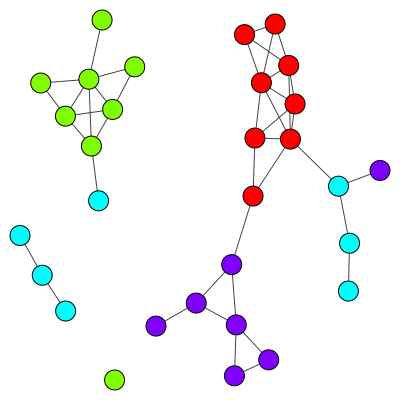

In [81]:
g1 = generate_sbm(n=30, c=4, p_in=0.4, p_out=0.01)
vs1 = visual_community_colors(g1)
ig.plot(g1, **vs1)

### Unweighted, directed

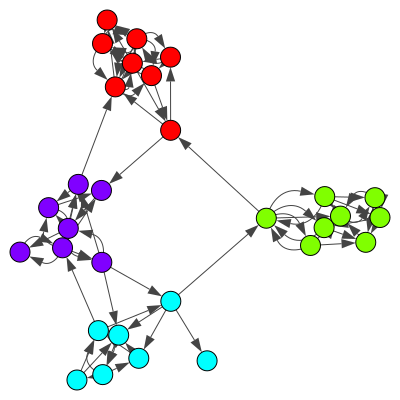

In [82]:
g1 = generate_sbm(n=30, c=4, p_in=0.4, p_out=0.01, directed=True)
vs1 = visual_community_colors(g1)
ig.plot(g1, **vs1)

### Weighted, undirected

### Weighted, directed